Определение корректора через яндекс спеллер

In [1]:
import requests
from manuscript.data import Page


class YandexSpellerCorrector:
    SPELLER_URL = "https://speller.yandex.net/services/spellservice.json/checkText"

    def __init__(self, lang: str = "ru"):
        self.lang = lang

    def predict(self, page: Page) -> Page:
        result = page.model_copy(deep=True)

        for block in result.blocks:
            for line in block.lines:
                for word in line.words:
                    if not word.text:
                        continue

                    corrected = self._correct_word(word.text)
                    if corrected:
                        word.text = corrected

        return result

    def _correct_word(self, text: str) -> str:
        try:
            response = requests.get(
                self.SPELLER_URL,
                params={
                    "text": text,
                    "lang": self.lang,
                },
                timeout=2,
            )
            response.raise_for_status()
            fixes = response.json()

            if not fixes:
                return text

            corrected = text
            for fix in reversed(fixes):
                if fix["s"]:
                    start = fix["pos"]
                    end = start + fix["len"]
                    corrected = (
                        corrected[:start]
                        + fix["s"][0]
                        + corrected[end:]
                    )

            return corrected

        except Exception:
            return text


c:\Users\pasha\manuscript-ocr\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[EAST] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
[TRBA] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
{'page': Page(blocks=[Block(lines=[Line(words=[Word(polygon=[(311.0214538574219, 472.00677490234375), (413.6349182128906, 472.00677490234375), (413.6349182128906, 548.1900634765625), (311.0214538574219, 548.1900634765625)], detection_confidence=0.9999982118606567, text='3)', recognition_confidence=0.862825334072113, order=0)], order=0)], words=[], order=0), Block(lines=[Line(words=[Word(polygon=[(449.0507507324219, 445.5913391113281), (932.2791748046875, 445.5913391113281), (932.2791748046875, 542.7658081054688), (449.0507507324

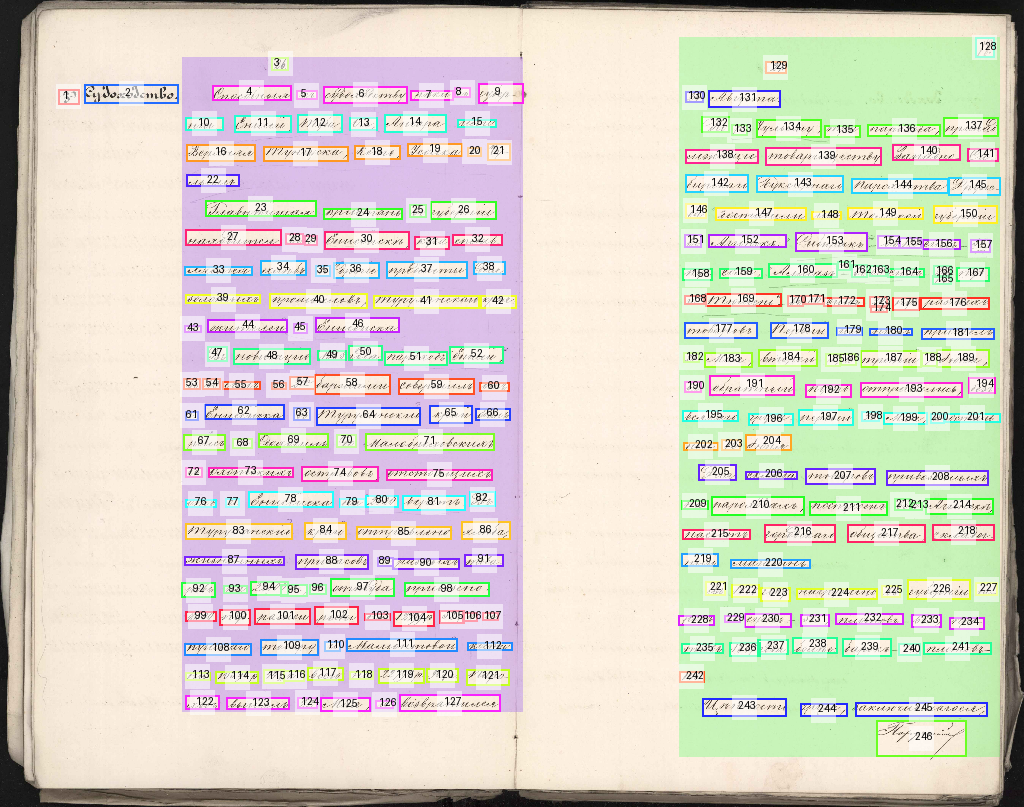

In [2]:
from huggingface_hub import hf_hub_download

from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page

model_path = hf_hub_download(
    repo_id="Daniil-Domino/yolo11x-text-detection",
    filename="model.pt"
)

image_path = "C:\\Users\\pasha\\manuscript-ocr\\example\\ocr_example_image.jpg"

pipeline = Pipeline(
    corrector=YandexSpellerCorrector(), 
)

result = pipeline.predict(image_path)

print(result)

text = pipeline.get_text(result["page"])
print(text)

visualize_page(
    image_path,
    result["page"],
    show_lines=False,
    show_numbers=True,
    max_size = 1024
)